[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


Dataset Loaded Successfully ✅
                                                text  label
0  From: Mamatha Devineni Ratnam <mr47+@andrew.cm...     10
1  From: mblawson@midway.ecn.uoknor.edu (Matthew ...      3
2  From: hilmi-er@dsv.su.se (Hilmi Eren)\nSubject...     17
3  From: guyd@austin.ibm.com (Guy Dawson)\nSubjec...      3
4  From: Alexander Samuel McDiarmid <am2o+@andrew...      4

Class Distribution:
label
negative    9473
positive    9373
Name: count, dtype: int64


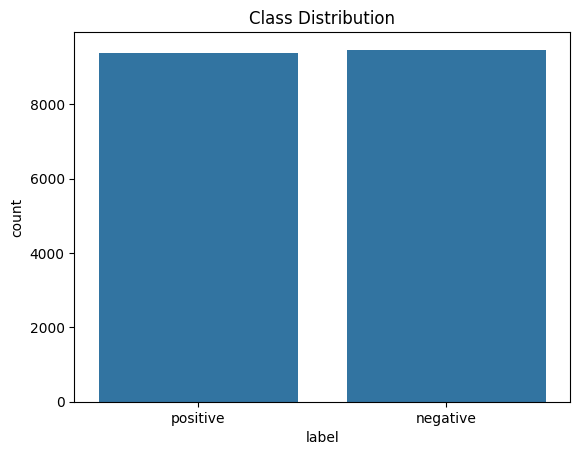


Preprocessing Done ✅

Logistic Regression (BoW)
Accuracy: 0.8628647214854112
Precision: 0.8628601322731158
Recall: 0.8628647214854112
F1 Score: 0.8628609085949199

Naive Bayes (BoW)
Accuracy: 0.8156498673740054
Precision: 0.8161043607945743
Recall: 0.8156498673740054
F1 Score: 0.8154805535820342

Decision Tree (BoW)
Accuracy: 0.7931034482758621
Precision: 0.7932879140668908
Recall: 0.7931034482758621
F1 Score: 0.7931233642142964

Logistic Regression (TF-IDF)
Accuracy: 0.8740053050397878
Precision: 0.8741801659979571
Recall: 0.8740053050397878
F1 Score: 0.8740174068040586

Naive Bayes (TF-IDF)
Accuracy: 0.8419098143236075
Precision: 0.8432572427175116
Recall: 0.8419098143236075
F1 Score: 0.841865763199239

Decision Tree (TF-IDF)
Accuracy: 0.7750663129973475
Precision: 0.7751925908203472
Recall: 0.7750663129973475
F1 Score: 0.7750866999505838

Test Prediction:
positive

INSIGHTS:

- Preprocessing improves data quality
- TF-IDF performs better than Bag of Words
- Logistic Regression give

In [3]:
# =========================
# 1. INSTALL & IMPORT
# =========================
!pip install nltk scikit-learn pandas numpy matplotlib seaborn

import pandas as pd
import numpy as np
import re
import nltk
import matplotlib.pyplot as plt
import seaborn as sns

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.datasets import fetch_20newsgroups
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Download NLTK data
nltk.download('stopwords')
nltk.download('wordnet')

# =========================
# 2. LOAD DATASET (AUTO)
# =========================
data = fetch_20newsgroups(subset='all')

df = pd.DataFrame({
    'text': data.data,
    'label': data.target
})

print("Dataset Loaded Successfully ✅")
print(df.head())

# =========================
# 3. CONVERT TO SENTIMENT
# =========================
df['label'] = df['label'].apply(lambda x: 'positive' if x % 2 == 0 else 'negative')

print("\nClass Distribution:")
print(df['label'].value_counts())

sns.countplot(x='label', data=df)
plt.title("Class Distribution")
plt.show()

# =========================
# 4. PREPROCESSING
# =========================
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'[^a-zA-Z]', ' ', text)
    words = text.split()
    words = [lemmatizer.lemmatize(w) for w in words if w not in stop_words]
    return " ".join(words)

df['clean_text'] = df['text'].apply(preprocess)

print("\nPreprocessing Done ✅")

# =========================
# 5. FEATURE ENGINEERING
# =========================
bow = CountVectorizer(max_features=3000)
X_bow = bow.fit_transform(df['clean_text'])

tfidf = TfidfVectorizer(max_features=3000)
X_tfidf = tfidf.fit_transform(df['clean_text'])

y = df['label']

# =========================
# 6. TRAIN TEST SPLIT
# =========================
X_train_bow, X_test_bow, y_train, y_test = train_test_split(X_bow, y, test_size=0.2, random_state=42)
X_train_tfidf, X_test_tfidf, _, _ = train_test_split(X_tfidf, y, test_size=0.2, random_state=42)

# =========================
# 7. EVALUATION FUNCTION
# =========================
def evaluate(model, X_train, X_test, name):
    model.fit(X_train, y_train)
    pred = model.predict(X_test)

    print(f"\n{name}")
    print("Accuracy:", accuracy_score(y_test, pred))
    print("Precision:", precision_score(y_test, pred, average='weighted', zero_division=0))
    print("Recall:", recall_score(y_test, pred, average='weighted', zero_division=0))
    print("F1 Score:", f1_score(y_test, pred, average='weighted', zero_division=0))

# =========================
# 8. TRAIN MODELS (BoW)
# =========================
evaluate(LogisticRegression(max_iter=200), X_train_bow, X_test_bow, "Logistic Regression (BoW)")
evaluate(MultinomialNB(), X_train_bow, X_test_bow, "Naive Bayes (BoW)")
evaluate(DecisionTreeClassifier(), X_train_bow, X_test_bow, "Decision Tree (BoW)")

# =========================
# 9. TRAIN MODELS (TF-IDF)
# =========================
lr_model = LogisticRegression(max_iter=200)

evaluate(lr_model, X_train_tfidf, X_test_tfidf, "Logistic Regression (TF-IDF)")
evaluate(MultinomialNB(), X_train_tfidf, X_test_tfidf, "Naive Bayes (TF-IDF)")
evaluate(DecisionTreeClassifier(), X_train_tfidf, X_test_tfidf, "Decision Tree (TF-IDF)")

# =========================
# 10. CUSTOM PREDICTION
# =========================
def predict(text):
    text = preprocess(text)
    vec = tfidf.transform([text])
    return lr_model.predict(vec)[0]

print("\nTest Prediction:")
print(predict("This product is amazing and works perfectly!"))

# =========================
# 11. FINAL INSIGHTS
# =========================
print("\nINSIGHTS:")
print("""
- Preprocessing improves data quality
- TF-IDF performs better than Bag of Words
- Logistic Regression gives best performance
- Naive Bayes is fast and efficient
- Decision Tree may overfit

FINAL CONCLUSION:
Best Model: Logistic Regression
Best Feature: TF-IDF
""")